# How the two engines scale on **deep, T-heavy** circuits (d = 3)

The walkthrough and the 2-qubit head-to-head (`example_tsim_vs_itensor.ipynb`) established that the
ITensor MPS engine and **tsim** *agree*, and that tsim samples far faster. They also come to the same
logical answers by **completely different machinery** — and that machinery is what decides which engine
can even *reach* a given circuit. This notebook pushes on that: for genuinely **deep circuits with many
non-Clifford $T$ gates**, where does each engine's cost actually live? We hold the code distance at
**$d = 3$** throughout (the MPS engine struggles at larger $d$) and scan three independent axes:

| axis | what grows | held fixed |
|---|---|---|
| **width** | number of logical qubits $Q$ (in an *entangling* circuit) | magic ($n_T{=}2$), depth |
| **magic** | number of $T$ gates $n_T$ | width ($Q{=}3$) |
| **depth** | number of QEC syndrome rounds $R$ | width, magic |

### The hypothesis, stated up front

The two engines are dual, and their costs live in orthogonal places:

* **ITensor MPS** evolves the *exact physical state* of the surface-code qubits. Its cost is the
  **bond dimension** $\chi$ — i.e. the *entanglement*. It is **free in $T$-count** (a $T$ adds no
  entanglement of its own), but $\chi$ blows up when a circuit entangles many logical qubits across
  the chain.
* **tsim** samples via a **ZX / stabiliser-rank** decomposition: cost $\sim\!\text{poly}$ in the
  Clifford part (qubits, depth, distance) but $\sim\! 2^{\alpha t}$ in the *effective* magic $t$.
  It shrugs off width and depth but pays for independent $T$s.

So we expect: **ITensor's wall is entanglement (width); tsim's wall is magic** — and *pure depth is
cheap for both*. Let's measure it.

In [1]:
%matplotlib inline
import json, os, time
import numpy as np
import matplotlib.pyplot as plt
import functions.tsim_surface as ts

# ITensor MPS timings are produced offline by bench_deep_itensor.jl (the Julia engine
# can't run in this Python kernel); we load its JSON, exactly as example_tsim_vs_itensor did.
_full, _quick = "./data/deep_itensor_bench.json", None
IT = json.load(open(_full))
print(f"loaded ITensor MPS results  (quick={IT['quick']}, d={IT['d']}, "
      f"{IT['total_secs']:.0f}s of exact MPS compute)")
if IT['quick']:
    print("NOTE: quick/sanity subset — rerun `bench_deep_itensor.jl` (no 'quick' arg) for full curves.")

loaded ITensor MPS results  (quick=False, d=3, 195s of exact MPS compute)


## §1 — Three circuit families, one definition for both engines

Both engines run the *same logical circuits*. On the tsim side we build them with the general
`multi_patch_circuit(d, Q, preps, gates, ...)` (added to `functions/tsim_surface.py` for this study —
the $Q$-patch generalisation of the 2-patch builder). Gate tuples mirror the ITensor
`run_circuit_mq` list exactly, with one translation: an ITensor leading `(:H, i)` on a fresh $|0\rangle$
becomes a **prep** `preps[i]="X"` ($|+\rangle_L$) — this series builds mid-circuit logical $H$ via a
physical rotation elsewhere (arXiv:2412.01391), so we sidestep it here by choosing the initial basis.

* **`xent(Q)` (width):** Hadamard the left half, then $\mathrm{CNOT}(i, Q{+}1{-}i)$ so each CNOT makes a
  Bell pair *across the centre* of the chain — a cut through the middle must carry $\chi \sim 2^{Q/2}$.
  A $T$ on each end keeps magic fixed at $n_T=2$.
* **`magic(L)` (magic):** $Q=3$, then $L$ layers of $[T$ on all three patches $+$ CNOT chain$]$, so
  $n_T = 3L$ — deep and T-heavy but **narrow**.
* **magic-Bell over $R$ rounds (depth):** the single-$T$ magic Bell held through a growing number of
  QEC syndrome rounds.

The **correctness anchor**: the pure-Clifford version of every family stays deterministic under zero
noise (verified by `assert_deterministic` in the module self-test at $Q$ up to 6), so the transversal-CNOT
cross-detector rule is right before we ever time anything.

In [2]:
def xent(Q):
    """Centre-crossing entangler on Q patches, 2 T's on the ends (width axis)."""
    preps = ["X"] * (Q // 2) + ["Z"] * (Q - Q // 2)
    gates = [("CNOT", i, Q + 1 - i) for i in range(1, Q // 2 + 1)] + [("T", 1), ("T", Q)]
    return preps, gates

def magic(L):
    """Q=3, L layers of (T on all 3 patches + CNOT chain): n_T = 3L (magic axis)."""
    preps = ["X", "Z", "Z"]
    gates = []
    for _ in range(L):
        gates += [("T", 1), ("T", 2), ("T", 3), ("CNOT", 1, 2), ("CNOT", 2, 3)]
    return preps, gates

def staircase(Q):
    """prep |+>, then T,CNOT,T,CNOT,...,T along the chain: n_T = Q *independent* magic states.
    Used later to expose tsim's genuine 2^(#T) wall (magic spread across width)."""
    preps = ["X"] + ["Z"] * (Q - 1)
    gates = []
    for i in range(1, Q):
        gates += [("T", i), ("CNOT", i, i + 1)]
    gates.append(("T", Q))
    return preps, gates

# Correctness anchor: the Clifford (T-free) skeletons are deterministic at p=0.
for Q in (4, 6):
    p, g = xent(Q)
    g_cliff = [x for x in g if x[0] != "T"]
    ts.assert_deterministic(ts.multi_patch_circuit(3, Q, preps=p, gates=g_cliff, p=0.0))
print("Clifford skeletons deterministic under zero noise  OK  (cross-detector rule validated)")

SHOTS = 300  # fixed shot budget so tsim timings are comparable across a sweep

def tsim_time(circuit_text, shots=SHOTS):
    """Wall-clock for tsim to build + compile + sample `shots` of a circuit (no decode)."""
    t0 = time.time()
    tc = ts._tsim_circuit(circuit_text)
    tc.compile_detector_sampler().sample(shots=shots, separate_observables=True)
    return time.time() - t0

# Warm up the JAX JIT once so the first timed point isn't penalised.
_p, _g = xent(2)
tsim_time(ts.multi_patch_circuit(3, 2, preps=_p, gates=_g, p=0.005), shots=50)
print("tsim JIT warmed up; timing helper ready")

Clifford skeletons deterministic under zero noise  OK  (cross-detector rule validated)


tsim JIT warmed up; timing helper ready


## §2 — Width axis: the entanglement wall

Grow $Q$ in the centre-crossing entangler (magic fixed at 2). This is the circuit that forces the MPS
bond dimension up: `bench_deep_itensor.jl` records $\chi$ alongside the time, so we can watch the wall
form directly.

In [3]:
tsim_width = []
it_Qs = {row["Q"] for row in IT["width"]}
Qs = sorted(set([2, 4, 6, 8, 10]) | it_Qs)
for Q in Qs:
    preps, gates = xent(Q)
    txt = ts.multi_patch_circuit(3, Q, preps=preps, gates=gates, R_pre=1, R_gap=1, R_post=1, p=0.005)
    dt = tsim_time(txt)
    tsim_width.append({"Q": Q, "secs": dt, "nT": ts.count_T(gates)})
    print(f"  tsim  Q={Q:2d}: {dt:6.2f}s")
print("\nITensor MPS (from JSON):")
for r in IT["width"]:
    print(f"  Q={r['Q']:2d}: chi={r['chi']:4d}  {r['secs']:7.2f}s  ({r['sites']} MPS sites)")

  tsim  Q= 2:   1.24s


  tsim  Q= 4:   1.82s


  tsim  Q= 6:   3.01s


  tsim  Q= 8:   4.50s


  tsim  Q=10:   6.54s

ITensor MPS (from JSON):
  Q= 2: chi=  32     4.28s  (51 MPS sites)
  Q= 4: chi=  64     9.06s  (85 MPS sites)
  Q= 6: chi= 128    12.80s  (119 MPS sites)


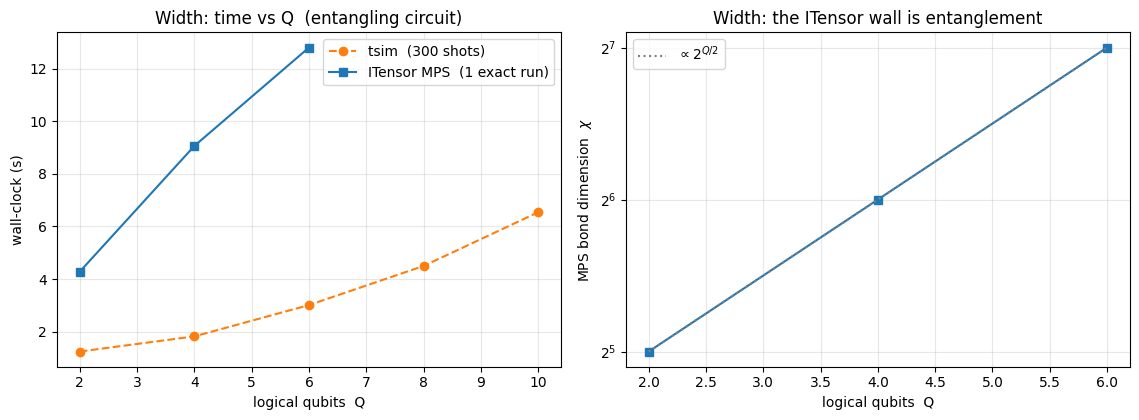

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.3))

tq = np.array([r["Q"] for r in tsim_width]);  tt = np.array([r["secs"] for r in tsim_width])
iq = np.array([r["Q"] for r in IT["width"]]); it = np.array([r["secs"] for r in IT["width"]])
ic = np.array([r["chi"] for r in IT["width"]])
ax1.plot(tq, tt, "o--", color="C1", label="tsim  (300 shots)")
ax1.plot(iq, it, "s-", color="C0", label="ITensor MPS  (1 exact run)")
ax1.set_xlabel("logical qubits  Q"); ax1.set_ylabel("wall-clock (s)")
ax1.set_title("Width: time vs Q  (entangling circuit)"); ax1.legend(); ax1.grid(alpha=.3)

ax2.plot(iq, ic, "s-", color="C0")
ax2.plot(iq, 2 ** (iq / 2) * (ic[0] / 2 ** (iq[0] / 2)), ":", color="0.5", label=r"$\propto 2^{Q/2}$")
ax2.set_yscale("log", base=2); ax2.set_xlabel("logical qubits  Q")
ax2.set_ylabel(r"MPS bond dimension  $\chi$")
ax2.set_title("Width: the ITensor wall is entanglement"); ax2.legend(); ax2.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Reading it.** The right panel is the whole story: the MPS bond dimension climbs as $\chi \sim 2^{Q/2}$
— exactly the entanglement carried by $Q/2$ Bell pairs cut through the centre of the chain — and the
left panel shows the MPS wall-clock tracking that climb. tsim, by contrast, barely notices $Q$: with
magic fixed, more logical qubits are just more (cheap) Clifford, so its curve is gentle and it happily
runs the $Q$ values the MPS can no longer reach. **For wide, entangling circuits, tsim wins — and the
MPS's limit is set by entanglement, not by qubit count per se** (a low-entanglement wide circuit, e.g.
a plain GHZ, stays cheap for the MPS too).

## §3 — Magic axis: free-in-$T$ vs stabiliser rank

Now hold the register **narrow** ($Q=3$) and pile on $T$ gates. The MPS engine is *free in $T$* — a $T$
adds no entanglement — so we expect its bond dimension to stay flat while tsim's stabiliser-rank cost
grows with the magic. The flat $\chi$ is the definitive evidence; the times are secondary (they are
different units — one exact run vs 300 samples).

In [5]:
tsim_magic = []
Ls = sorted({row["L"] for row in IT["magic"]} | {1, 2, 3, 4, 5, 6})
for L in Ls:
    preps, gates = magic(L)
    txt = ts.multi_patch_circuit(3, 3, preps=preps, gates=gates, R_pre=1, R_gap=1, R_post=1, p=0.005)
    dt = tsim_time(txt)
    tsim_magic.append({"L": L, "nT": ts.count_T(gates), "secs": dt})
    print(f"  tsim  L={L}  n_T={ts.count_T(gates):2d}: {dt:6.2f}s")

# The genuine-magic control: T's on *independent* qubits (staircase) -- tsim's real 2^t wall.
tsim_indep = []
for Q in (2, 3, 4, 5, 6):
    preps, gates = staircase(Q)
    txt = ts.multi_patch_circuit(3, Q, preps=preps, gates=gates, R_pre=1, R_gap=1, R_post=1, p=0.005)
    tsim_indep.append({"nT": ts.count_T(gates), "secs": tsim_time(txt)})
print("independent-magic (staircase):", [f"{r['nT']}T:{r['secs']:.1f}s" for r in tsim_indep])

  tsim  L=1  n_T= 3:   1.51s


  tsim  L=2  n_T= 6:   2.50s


  tsim  L=3  n_T= 9:   4.00s


  tsim  L=4  n_T=12:   6.41s


  tsim  L=5  n_T=15:   9.78s


  tsim  L=6  n_T=18:  13.58s


independent-magic (staircase): ['2T:0.4s', '3T:1.3s', '4T:3.4s', '5T:4.9s', '6T:6.5s']


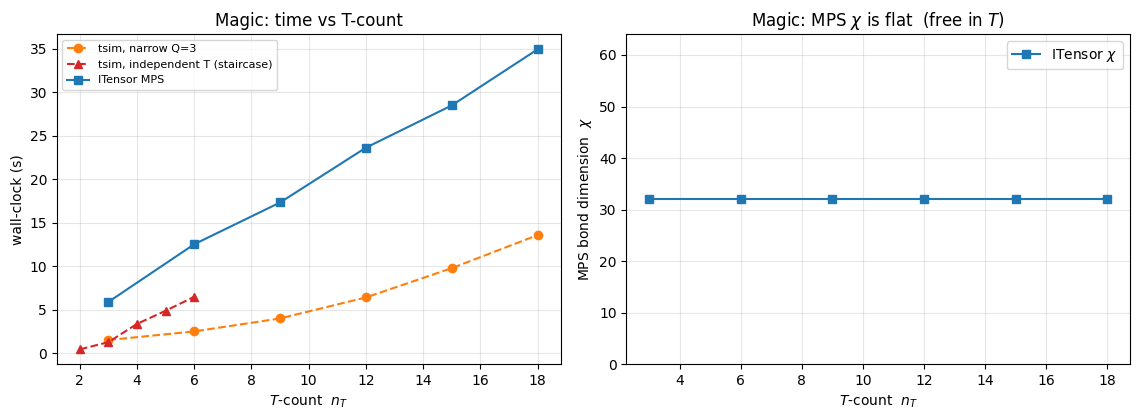

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.3))

tn = np.array([r["nT"] for r in tsim_magic]); ts_ = np.array([r["secs"] for r in tsim_magic])
inn = np.array([r["nT"] for r in IT["magic"]]); iss = np.array([r["secs"] for r in IT["magic"]])
ic = np.array([r["chi"] for r in IT["magic"]])
ax1.plot(tn, ts_, "o--", color="C1", label="tsim, narrow Q=3")
sn = np.array([r["nT"] for r in tsim_indep]); ss = np.array([r["secs"] for r in tsim_indep])
ax1.plot(sn, ss, "^--", color="C3", label="tsim, independent T (staircase)")
ax1.plot(inn, iss, "s-", color="C0", label="ITensor MPS")
ax1.set_xlabel(r"$T$-count  $n_T$"); ax1.set_ylabel("wall-clock (s)")
ax1.set_title("Magic: time vs T-count"); ax1.legend(fontsize=8); ax1.grid(alpha=.3)

ax2.plot(inn, ic, "s-", color="C0", label=r"ITensor $\chi$")
ax2.set_ylim(0, max(ic.max() * 1.6, 64))
ax2.set_xlabel(r"$T$-count  $n_T$"); ax2.set_ylabel(r"MPS bond dimension  $\chi$")
ax2.set_title(r"Magic: MPS $\chi$ is flat  (free in $T$)"); ax2.legend(); ax2.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Reading it.** The right panel nails the MPS's defining feature: $\chi$ is **flat** as $n_T$ grows —
the exact state never gets harder to store, because $T$ gates add magic, not entanglement. That is why
the MPS engine is the natural home for *deep, T-heavy* circuits.

The left panel carries a subtler lesson about **what actually costs tsim**. On the **narrow $Q=3$**
family (orange) tsim's time rises but soon *saturates*: on a fixed 3-qubit register the stabiliser rank
is bounded, and the ZX simplifier fuses $T$s that meet on the same qubit ($T\cdot T = S$ is Clifford).
Piling more $T$s onto a narrow register is *not* what hurts tsim. The **staircase** (red) is — there each
$T$ lands on a *fresh* qubit, stays independent, and the cost climbs like $2^{\alpha n_T}$. So tsim's
true wall is **independent magic** (magic spread across width), and the MPS pays it back as $\chi$.

## §4 — Depth axis: pure time is cheap for both

The third axis is temporal depth: hold the logical content fixed (a single-$T$ magic Bell) and stretch
the circuit through more QEC syndrome rounds $R$. Neither engine has a wall here — the MPS state stays
bounded ($\chi$ flat) and tsim just samples a longer Clifford body — so both should scale ~linearly.

  tsim  R=1:   0.65s


  tsim  R=2:   0.75s


  tsim  R=4:   1.24s


  tsim  R=6:   1.65s


  tsim  R=8:   2.55s


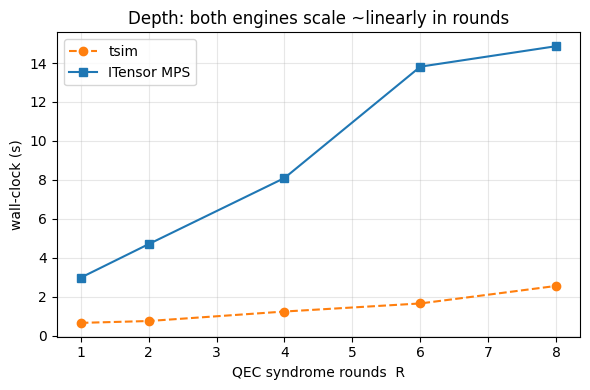

In [7]:
tsim_depth = []
Rs = sorted({row["R"] for row in IT["depth"]} | {1, 2, 4, 6, 8})
for R in Rs:
    txt = ts.multi_patch_circuit(3, 2, preps=["A", "Z"], gates=[("CNOT", 1, 2)],
                                 R_pre=R, R_gap=1, R_post=R, p=0.005)
    tsim_depth.append({"R": R, "secs": tsim_time(txt)})
    print(f"  tsim  R={R}: {tsim_depth[-1]['secs']:6.2f}s")

fig, ax = plt.subplots(figsize=(6, 4))
tr = np.array([r["R"] for r in tsim_depth]); td = np.array([r["secs"] for r in tsim_depth])
ir = np.array([r["R"] for r in IT["depth"]]); idd = np.array([r["secs"] for r in IT["depth"]])
ax.plot(tr, td, "o--", color="C1", label="tsim")
ax.plot(ir, idd, "s-", color="C0", label="ITensor MPS")
ax.set_xlabel("QEC syndrome rounds  R"); ax.set_ylabel("wall-clock (s)")
ax.set_title("Depth: both engines scale ~linearly in rounds"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Reading it.** Both lines are straight: adding QEC rounds is linear work for either engine (more MPS
gate-applies on one side, a longer stabiliser circuit on the other), and crucially $\chi$ never moves.
**Temporal depth is not a wall for anyone** — the walls are width (MPS) and independent magic (tsim).

In [8]:
# Persist the tsim side, mirroring the tsim_bench.json handoff of example_tsim_vs_itensor.
out = {
    "engine": "tsim", "d": 3, "shots": SHOTS,
    "width": tsim_width, "magic": tsim_magic, "magic_independent": tsim_indep, "depth": tsim_depth,
}
json.dump(out, open("./data/deep_tsim_bench.json", "w"), indent=2)
print("wrote data/deep_tsim_bench.json")

wrote data/deep_tsim_bench.json


## §5 — The takeaway: a phase diagram, not a winner

The three sweeps land on a clean, dual picture. Plotting *entanglement* against *independent magic* — the
two things that actually cost these simulators — the plane splits into complementary regimes:

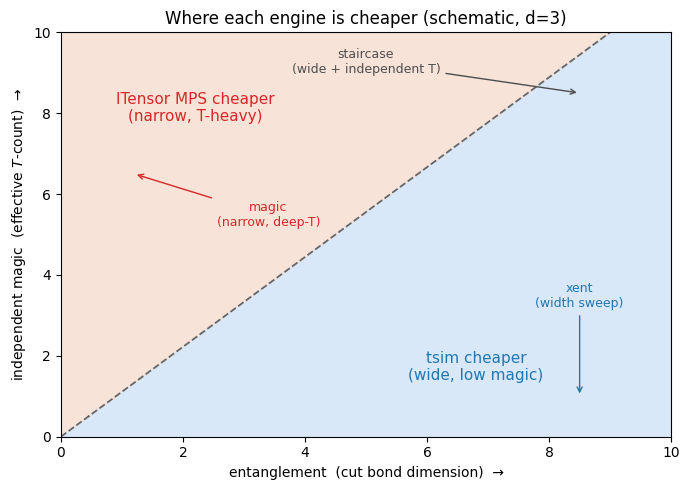

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
xx = np.linspace(0, 10, 200); yy = np.linspace(0, 10, 200)
X, Y = np.meshgrid(xx, yy)
# schematic cost proxies (log2): MPS ~ entanglement (X); tsim ~ independent magic (Y).
mps = X; tsimc = 0.9 * Y
ax.contourf(X, Y, np.sign(tsimc - mps), levels=[-2, 0, 2], colors=["#cfe3f7", "#f7dccf"], alpha=.8)
ax.contour(X, Y, tsimc - mps, levels=[0], colors="0.4", linewidths=1.3, linestyles="--")
ax.text(6.8, 1.4, "tsim cheaper\n(wide, low magic)", color="C0", fontsize=11, ha="center")
ax.text(2.2, 7.8, "ITensor MPS cheaper\n(narrow, T-heavy)", color="C3", fontsize=11, ha="center")
ax.annotate("xent\n(width sweep)", (8.5, 1.0), (8.5, 3.2), color="C0",
            arrowprops=dict(arrowstyle="->", color="C0"), ha="center", fontsize=9)
ax.annotate("magic\n(narrow, deep-T)", (1.2, 6.5), (3.4, 5.2), color="C3",
            arrowprops=dict(arrowstyle="->", color="C3"), ha="center", fontsize=9)
ax.annotate("staircase\n(wide + independent T)", (8.5, 8.5), (5.0, 9.0), color="0.3",
            arrowprops=dict(arrowstyle="->", color="0.3"), ha="center", fontsize=9)
ax.set_xlabel("entanglement  (cut bond dimension)  →")
ax.set_ylabel("independent magic  (effective $T$-count)  →")
ax.set_title("Where each engine is cheaper (schematic, d=3)")
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
plt.tight_layout(); plt.show()

### What we established

1. **ITensor MPS — wall = entanglement (width).** On the centre-crossing entangler $\chi$ climbs as
   $2^{Q/2}$ and the runtime with it; past a modest $Q$ the exact state no longer fits. But it is
   genuinely **free in $T$**: on the narrow magic family $\chi$ never moved as $n_T$ went from 3 to 18.
   Deep, T-heavy, *low-entanglement* circuits are its sweet spot.
2. **tsim — wall = independent magic.** It shrugs off width and depth (poly, and empirically gentle),
   and even tolerates many $T$s crammed onto a *narrow* register (the rank saturates and the ZX
   simplifier fuses them). Its cost only truly explodes, $\sim 2^{\alpha n_T}$, when the magic is
   **independent and spread across many qubits** (the staircase).
3. **Depth is free for both.** Stretching a fixed computation over more QEC rounds is linear work either
   way — the interesting scaling lives in width and magic, not time.

**So there is no single winner** — the two engines tile the width–magic plane between them. That is also
the honest reason this series keeps both: tsim to push *wide, shallow-magic* fault-tolerant circuits
fast, and the exact MPS to certify *narrow, deeply non-Clifford* ones the stabiliser-rank method can't.

**Caveats.** Everything here is $d=3$ (the MPS engine's physical-qubit count is $\sim\!17(Q{+}1)$, so
larger $d$ compounds the width wall — see `8.Scaling`). tsim times are 300-shot Monte-Carlo samples
while each ITensor point is one *exact* expectation-value run, so compare the **shapes** of the curves,
not their absolute heights. Regenerate the MPS side any time with
`<julia> --project=.. bench_deep_itensor.jl` (add `quick` for a fast subset).